vector store v/s vector DB

### Vector Store vs Vector Database

| Feature | Vector Store | Vector Database |
|---|---|---|
| **Meaning** | A system/component that **stores and retrieves vectors** | A **full database system** designed to manage vector data |
| **Main Purpose** | Store embeddings + perform similarity search | Store, search, manage, filter, index, and operate on vector data at scale |
| **Database Features** | Usually limited | Usually provides database-like features |
| **Persistence** | Can be in-memory or persistent | Normally persistent |
| **Metadata Filtering** | May be supported | Usually strongly supported |
| **Indexing** | Basic/specialized vector indexes | Advanced indexing + database management |
| **Scalability** | Often suitable for smaller/simple use cases | Designed for large-scale applications |
| **Transactions** | Usually limited/not the focus | May support transactions and concurrency |
| **Distributed Systems** | Usually not the main focus | Often supports distributed deployment |
| **Examples** | FAISS, Chroma used through LangChain | Pinecone, Milvus, Qdrant, Weaviate, pgvector |
| **Best For** | RAG prototypes, local applications, experimentation | Production-scale RAG/search systems |

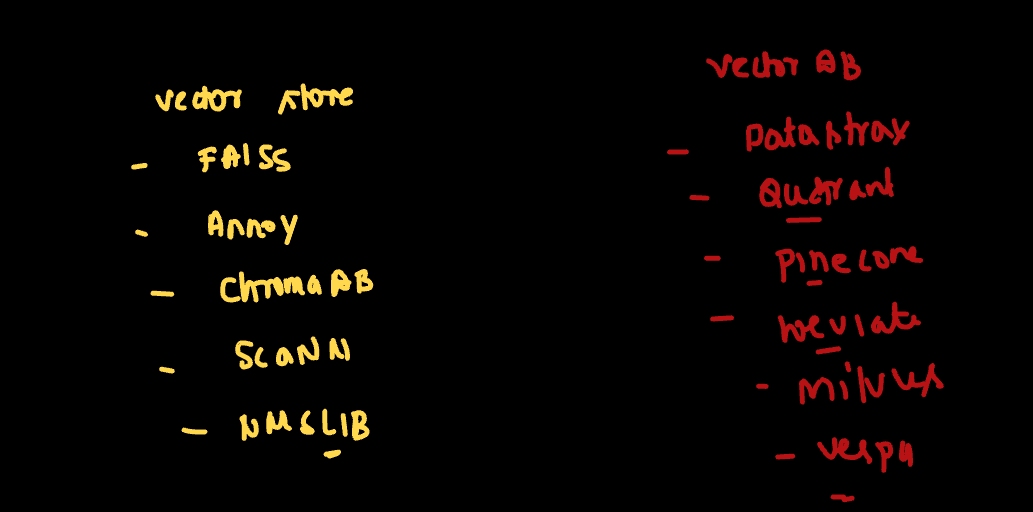

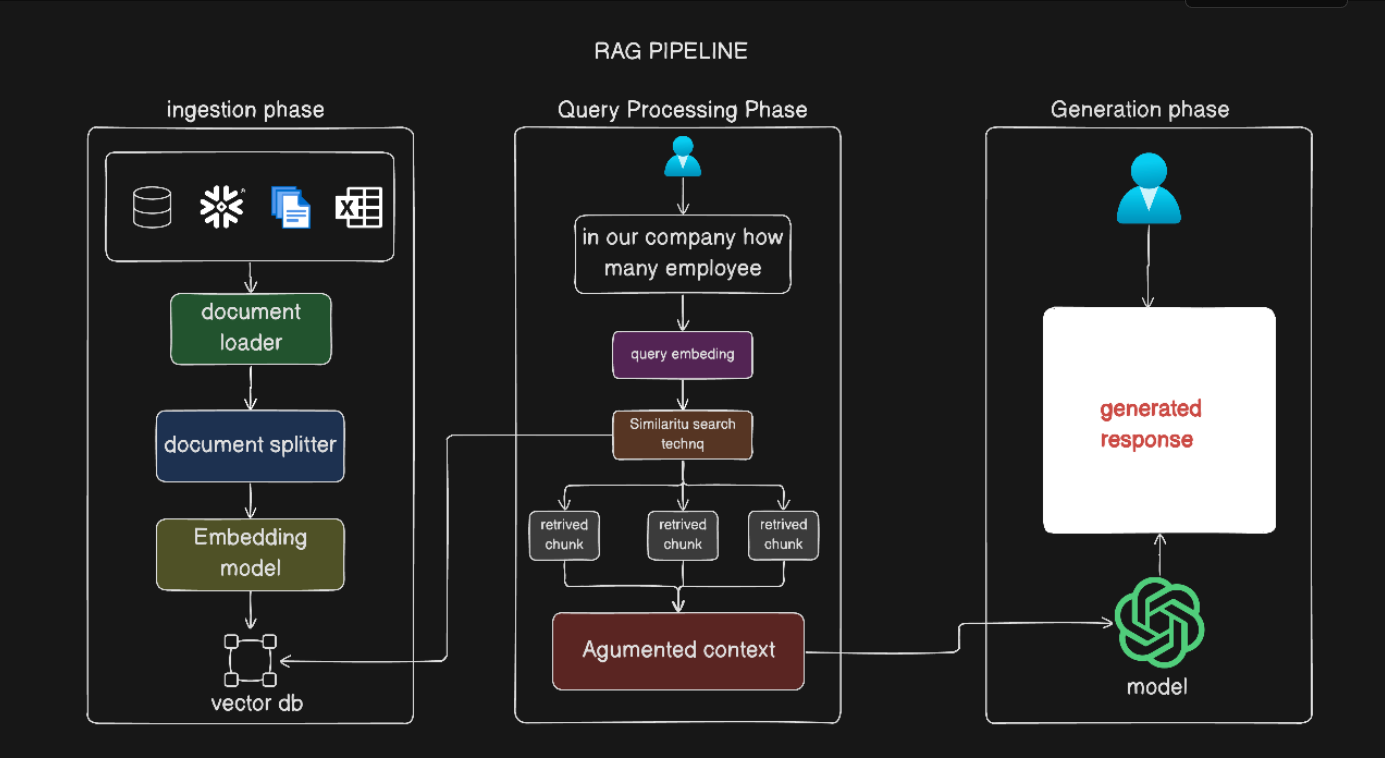

In [2]:
# Libraries import
import os 
from dotenv import load_dotenv
load_dotenv(override=True)
## text loading # directory load #embediings # text splitting
from langchain_community.document_loaders import DirectoryLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_openai import OpenAIEmbeddings

# vector store
from langchain_community.vectorstores import Chroma

#prompt template and LCEL
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser




In [ ]:
# stage 1: Load Document 
from docx import document


dir_loader = DirectoryLoader(
    "data",
    glob = "*.txt", # pattern that matches the files
    loader_cls=TextLoader,
    loader_kwargs={
        'encoding':'utf-8'
    },
)

documents = dir_loader.load()
print(f"Total document loaded: {len(documents)}")

Total document loaded: 4


In [4]:
documents[0]

Document(metadata={'source': 'data/python.txt'}, page_content='Python is a high-level, interpreted, \ngeneral-purpose programming language known for its simple syntax and readability. \nIt is widely used in software development, automation, data science, artificial intelligence, \nmachine learning, web development, and DevOps. Python provides many built-in libraries and has a large ecosystem of third-party packages. Frameworks such as FastAPI, Flask, and Django help developers build web applications and APIs. Python is also popular in automation because developers can easily write scripts for managing infrastructure, processing files, interacting with APIs, and performing repetitive tasks. Its simplicity and versatility make Python one of the most widely used programming languages in modern technology.')

In [5]:
print(documents[0].page_content[:100])

Python is a high-level, interpreted, 
general-purpose programming language known for its simple synt


In [6]:
# Stage 2: Document Splitting

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap = 50,
    length_function = len,
    separators= [" "]
)

chunks = text_splitter.split_documents(documents)
print(f"created {len(chunks)} chunks from {len(documents)} documents")

created 19 chunks from 4 documents


In [7]:

print("content: ")
print(chunks[0].page_content)

print("Metadata: ")
print(chunks[0].metadata)

content: 
Python is a high-level, interpreted, 
general-purpose programming language known for its simple syntax and readability. 
It is widely used in software development, automation, data science, artificial intelligence, 
machine learning, web development, and DevOps. Python provides many built-in libraries and has a large ecosystem of third-party packages. Frameworks such as FastAPI, Flask, and Django help developers build web applications and APIs. Python is also popular in automation because
Metadata: 
{'source': 'data/python.txt'}


In [10]:
# Stage-3 Create Embeding Model

embeddings = HuggingFaceEmbeddings(
    model = 'sentence-transformers/all-MiniLM-L6-v2'
    )


sample_text = "Hello Everyone how are you..."

vector = embeddings.embed_query(sample_text)
print(vector[:10])

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6119.60it/s]


[-0.0021842780988663435, 0.03727424517273903, 0.0886002629995346, 0.051501210778951645, -0.024976201355457306, -0.0810340866446495, 0.0802222415804863, -0.012102126143872738, -0.010524536482989788, 0.018259596079587936]


In [ ]:
# Stage-4 Vectore Store Creation

persist_directry = "./chroma_db"

vectore_store = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    persist_directory=persist_directry,
    collection_name="ITK_Rag_Collection"
)

In [ ]:
# Stage-5 Similiarity Search
query = "What is the Dadasaheb Phalke Award?"

similar_docs = vectore_store.similarity_search(
    query,
    k=3
)

similar_docs

[Document(metadata={'source': 'data/award.txt'}, page_content="for the year 2024, India's highest honour in the field of cinema. President Droupadi Murmu presented the award to him at the 72nd National Film Awards ceremony held at Ekta Nagar, Kevadia, Gujarat, on September 22, 2026.\n\n## What is the Dadasaheb Phalke Award?\n\nThe Dadasaheb Phalke Award was instituted by the Government of India in 1969 to commemorate Dadasaheb Phalke, who directed India's first full-length feature film, Raja Harishchandra, in 1913.\n\nThe award recognizes outstanding"),
 Document(metadata={'source': 'data/award.txt'}, page_content='connected Kannada cinema with audiences across India.\n\nHe has spent decades working in Kannada cinema while also contributing to other Indian-language film industries. His ability to bring authenticity to characters made him recognizable to audiences beyond linguistic boundaries.\n\nHis Dadasaheb Phalke Award therefore represents not only an individual achievement but also

In [13]:
similar_docs[0].page_content

"for the year 2024, India's highest honour in the field of cinema. President Droupadi Murmu presented the award to him at the 72nd National Film Awards ceremony held at Ekta Nagar, Kevadia, Gujarat, on September 22, 2026.\n\n## What is the Dadasaheb Phalke Award?\n\nThe Dadasaheb Phalke Award was instituted by the Government of India in 1969 to commemorate Dadasaheb Phalke, who directed India's first full-length feature film, Raja Harishchandra, in 1913.\n\nThe award recognizes outstanding"

In [14]:
query = "What is the Dadasaheb Phalke Award?"

result_score=vectore_store.similarity_search_with_score(
    query,
    k=3
)

In [15]:
result_score

[(Document(metadata={'source': 'data/award.txt'}, page_content="for the year 2024, India's highest honour in the field of cinema. President Droupadi Murmu presented the award to him at the 72nd National Film Awards ceremony held at Ekta Nagar, Kevadia, Gujarat, on September 22, 2026.\n\n## What is the Dadasaheb Phalke Award?\n\nThe Dadasaheb Phalke Award was instituted by the Government of India in 1969 to commemorate Dadasaheb Phalke, who directed India's first full-length feature film, Raja Harishchandra, in 1913.\n\nThe award recognizes outstanding"),
  0.6595205068588257),
 (Document(metadata={'source': 'data/award.txt'}, page_content='connected Kannada cinema with audiences across India.\n\nHe has spent decades working in Kannada cinema while also contributing to other Indian-language film industries. His ability to bring authenticity to characters made him recognizable to audiences beyond linguistic boundaries.\n\nHis Dadasaheb Phalke Award therefore represents not only an indivi

In [16]:
for doc,score in result_score:
    print("\nScore:", score)
    print(doc.page_content[:300]) 


Score: 0.6595205068588257
for the year 2024, India's highest honour in the field of cinema. President Droupadi Murmu presented the award to him at the 72nd National Film Awards ceremony held at Ekta Nagar, Kevadia, Gujarat, on September 22, 2026.

## What is the Dadasaheb Phalke Award?

The Dadasaheb Phalke Award was institu

Score: 0.7427588701248169
connected Kannada cinema with audiences across India.

He has spent decades working in Kannada cinema while also contributing to other Indian-language film industries. His ability to bring authenticity to characters made him recognizable to audiences beyond linguistic boundaries.

His Dadasaheb Phal

Score: 0.8694794178009033
# Anant Nag and the Dadasaheb Phalke Award: A Golden Recognition for Kannada Cinema

Indian cinema is not just about entertainment. It is a reflection of our culture, language, emotions, traditions and society. Over the decades, many artists have dedicated their lives to enriching Indian cinema. Amo


In [21]:
#stage-6 creating retriver
retriever = vectore_store.as_retriever(
    search_kwargs={
        "k": 3
    }
)

In [19]:
query = "What is the Dadasaheb Phalke Award?"
retrived_docs = retriever.invoke(query)
retrived_docs

[Document(metadata={'source': 'data/award.txt'}, page_content="for the year 2024, India's highest honour in the field of cinema. President Droupadi Murmu presented the award to him at the 72nd National Film Awards ceremony held at Ekta Nagar, Kevadia, Gujarat, on September 22, 2026.\n\n## What is the Dadasaheb Phalke Award?\n\nThe Dadasaheb Phalke Award was instituted by the Government of India in 1969 to commemorate Dadasaheb Phalke, who directed India's first full-length feature film, Raja Harishchandra, in 1913.\n\nThe award recognizes outstanding"),
 Document(metadata={'source': 'data/award.txt'}, page_content='connected Kannada cinema with audiences across India.\n\nHe has spent decades working in Kannada cinema while also contributing to other Indian-language film industries. His ability to bring authenticity to characters made him recognizable to audiences beyond linguistic boundaries.\n\nHis Dadasaheb Phalke Award therefore represents not only an individual achievement but also

In [20]:
for i, doc in enumerate(retrived_docs, start=1):
    print(f"\n--- Retrieved Document {i} ---")
    print(doc.page_content)
    print("Metadata:", doc.metadata)
    


--- Retrieved Document 1 ---
for the year 2024, India's highest honour in the field of cinema. President Droupadi Murmu presented the award to him at the 72nd National Film Awards ceremony held at Ekta Nagar, Kevadia, Gujarat, on September 22, 2026.

## What is the Dadasaheb Phalke Award?

The Dadasaheb Phalke Award was instituted by the Government of India in 1969 to commemorate Dadasaheb Phalke, who directed India's first full-length feature film, Raja Harishchandra, in 1913.

The award recognizes outstanding
Metadata: {'source': 'data/award.txt'}

--- Retrieved Document 2 ---
connected Kannada cinema with audiences across India.

He has spent decades working in Kannada cinema while also contributing to other Indian-language film industries. His ability to bring authenticity to characters made him recognizable to audiences beyond linguistic boundaries.

His Dadasaheb Phalke Award therefore represents not only an individual achievement but also a moment of recognition for the richnes

In [23]:
# stage-7 we initiating LLMs

from langchain_groq import ChatGroq
llm = ChatGroq(
    model = "openai/gpt-oss-120b"
)

In [24]:
respo = llm.invoke("hi")

In [26]:
respo.content

'Hello! How can I assist you today?'

In [27]:
#STAGE-8 CREATING THE RAG TEMPLATE
custom_prompt = ChatPromptTemplate.from_template("""
You are a helpful assistant.

Answer the question using ONLY the provided context.

If the answer cannot be found in the context, say:
"I don't know based on the provided documents."

Context:
{context}

Question:
{question}

Answer:
""")


In [28]:
# STAGE-9 BUILDING COMPLETE RAG

ragchain = (
    {
        "context": retriever,
        "question": RunnablePassthrough()
    }
    | custom_prompt
    | llm
    | StrOutputParser()
)

In [29]:
# TESTING PHASE:
question = "What is the Dadasaheb Phalke Award?"

answer = ragchain.invoke(question)

print(answer)

The Dadasaheb Phalke Award is India’s highest honour in the field of cinema. It was instituted by the Government of India in 1969 to commemorate Dadasaheb Phalke, who directed India’s first full‑length feature film, *Raja Harishchandra* (1913), and it recognises outstanding contributions to Indian cinema.


In [30]:
question = "can you sing song for me becuse its 1:00AM"

answer = ragchain.invoke(question)

print(answer)

I don't know based on the provided documents.


                  USER QUESTION
                        │
                        ▼
               "What is the award?"
                        │
              ┌─────────┴─────────┐
              │                   │
              ▼                   ▼
          retriever         RunnablePassthrough
              │                   │
              ▼                   │
      Search ChromaDB             │
              │                   │
              ▼                   │
       Relevant chunks            │
              │                   │
              └─────────┬─────────┘
                        ▼
                  ChatPromptTemplate
                        │
                        ▼
                       LLM
                        │
                        ▼
                  StrOutputParser
                        │
                        ▼
                  FINAL ANSWER